# Telco customer churn: can we identify customers at risk?

This executed notebook covers the full Option A workflow: data checks, training-only exploratory analysis, feature engineering, leakage-safe preprocessing, model comparison, held-out evaluation, a descriptive subgroup audit and export of one complete prediction pipeline. The dataset is a static IBM educational sample distributed through Kaggle.

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Image

import churn_analysis as ca

PROJECT = Path.cwd()
DATA = PROJECT / "data" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"
OUT = PROJECT
print("Data:", DATA.name)
print("Random state:", ca.SEED)

Data: WA_Fn-UseC_-Telco-Customer-Churn.csv
Random state: 42


## Load and inspect the supplied data

The target is `Churn`. The full file is used because the supplied selected-columns file has no target and omits contract and charge fields.

In [2]:
df = pd.read_csv(DATA)
quality = ca.inspect_data(df, DATA)
print("Shape:", df.shape)
print("Columns:", list(df.columns))
print("Quality checks:")
print(json.dumps(quality, indent=2))
display(df.head(3))

Shape: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
Quality checks:
{
  "source_file": "WA_Fn-UseC_-Telco-Customer-Churn.csv",
  "source_sha256": "88be4b93fbe0cc83421af1c503794c97c342eca914c1576db7c276e61d61358a",
  "local_inspection_date": "2026-10-03",
  "rows": 7043,
  "columns": 21,
  "unique_customer_ids": 7043,
  "duplicate_rows": 0,
  "duplicate_ids": 0,
  "blank_TotalCharges": 11,
  "missing_TotalCharges_after_numeric_conversion": 11,
  "blank_TotalCharges_with_zero_tenure": 11,
  "other_missing_cells": 0,
  "negative_tenure_or_charges": 0,
  "churn_count": 1869,
  "nonchurn_count": 5174,
  "churn_rate": 0.2653698707936959
}


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


## Split before learning preprocessing

The identifier is retained in the raw table for audit output, but `TelcoFeatures` excludes it from model inputs. The split is stratified so the churn share is similar in train and test. The test set is held back until model selection is finished.

In [3]:
X = df.drop(columns="Churn")
y = df["Churn"].eq("Yes").astype(int)
X_train, X_test, y_train, y_test = ca.train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=ca.SEED
)
print("Train rows:", len(X_train), "Test rows:", len(X_test))
print("Train churn rate:", round(y_train.mean(), 4), "Test churn rate:", round(y_test.mean(), 4))
assert set(X_train.customerID).isdisjoint(X_test.customerID)

Train rows: 5634 Test rows: 1409
Train churn rate: 0.2654 Test churn rate: 0.2654


## Training-only exploratory analysis

The figures and rates below are calculated from training rows. They describe associations in this sample and do not establish causation.

In [4]:
eda = ca.explore_training(X_train, y_train, OUT)
print("Contract rates:")
display(pd.DataFrame(eda["Contract"]))
print("Internet-service rates:")
display(pd.DataFrame(eda["InternetService"]))
print("Median numeric values by observed churn:")
display(pd.DataFrame(eda["by_churn"]))

Contract rates:


,Contract,customers,churners,churn_rate
0,Month-to-month,3102,1326,0.427466
1,One year,1173,130,0.110827
2,Two year,1359,39,0.028698


Internet-service rates:


,InternetService,customers,churners,churn_rate
0,Fiber optic,2483,1045,0.420862
1,DSL,1937,362,0.186887
2,No,1214,88,0.072488


Median numeric values by observed churn:


,Churn label,customers,median_tenure,median_monthly_charges
0,No,4139,38.0,64.40
1,Yes,1495,10.0,79.95


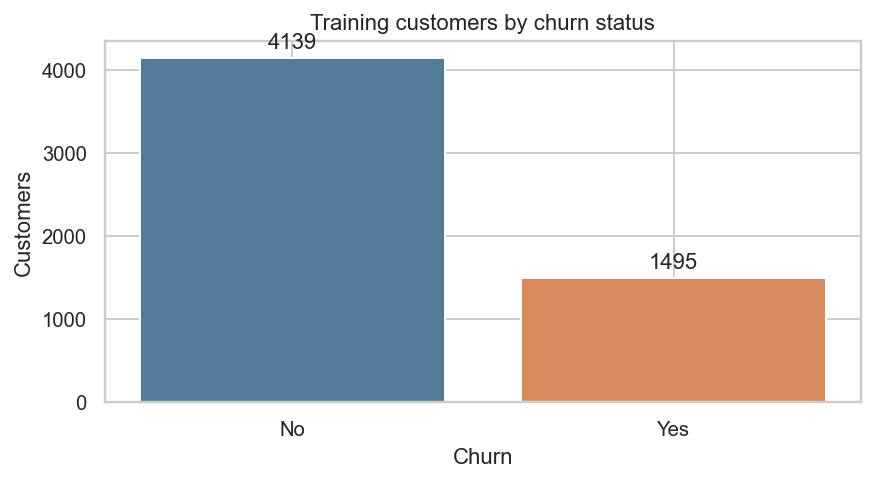

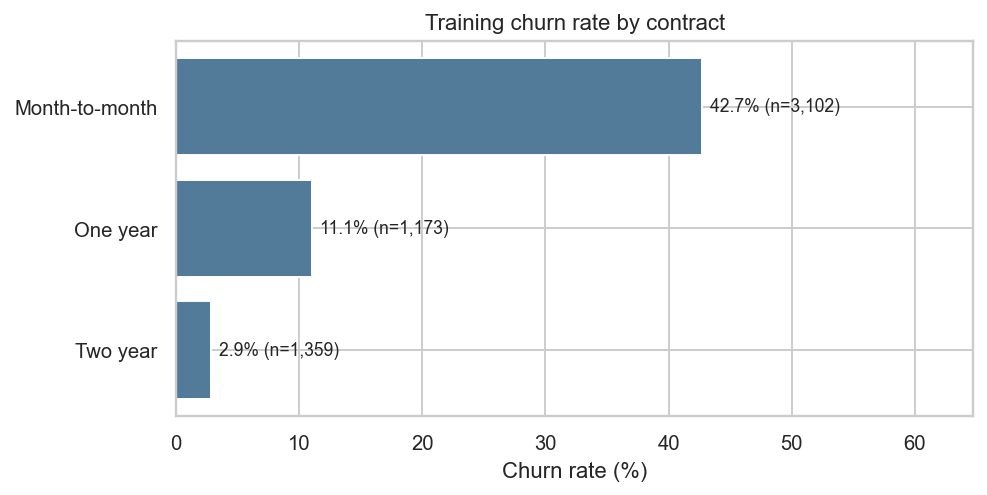

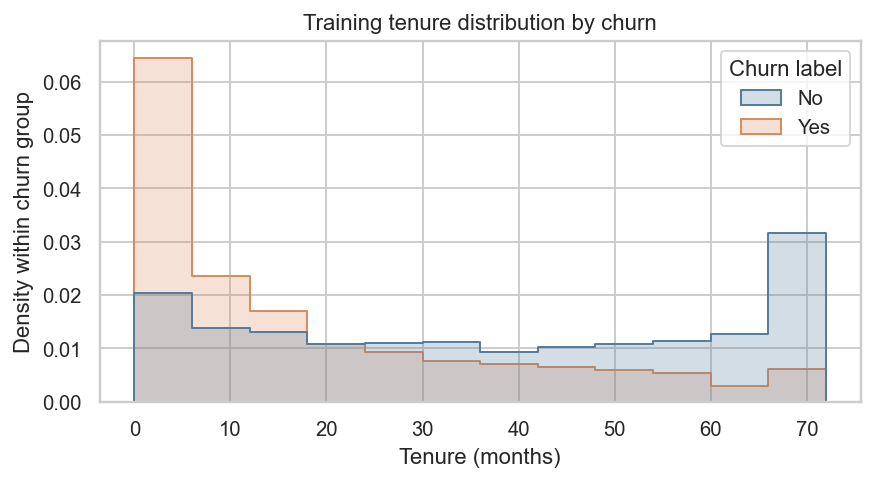

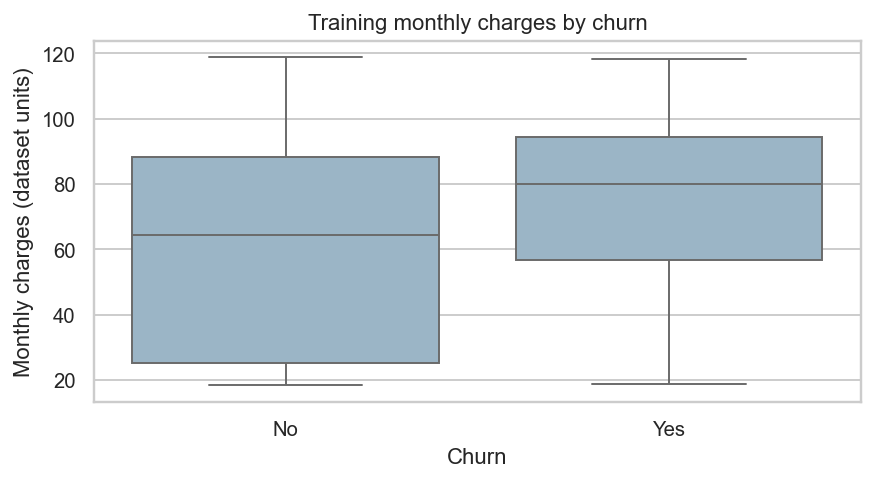

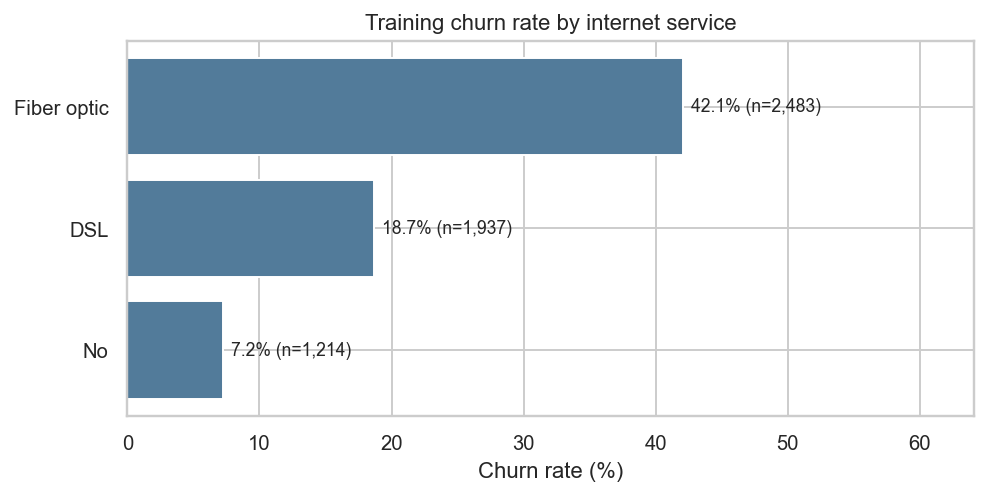

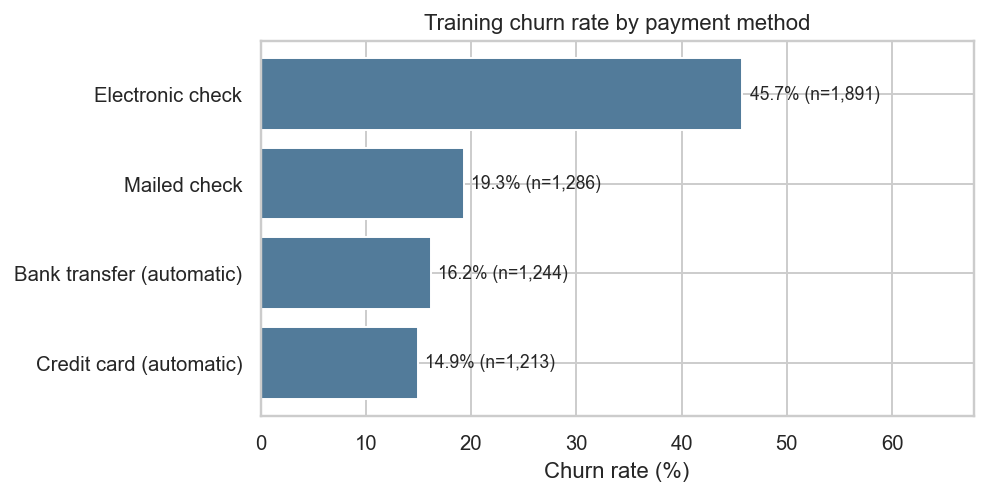

In [5]:
for figure in sorted((PROJECT / "figures").glob("0[1-6]_*.png")):
    display(Image(filename=str(figure)))

## Feature engineering and model pipelines

`ServiceCount` counts six optional services. `TenureBand` groups tenure into relationship stages. Numeric imputation and scaling, categorical imputation and one-hot encoding are fitted inside each training fold. This keeps learned preprocessing away from validation and test rows.

In [6]:
feature_example = ca.TelcoFeatures().fit_transform(X_train.head(5))
display(feature_example[["tenure", "ServiceCount", "TenureBand"]])
print("A pipeline contains TelcoFeatures, ColumnTransformer preprocessing and a classifier.")

,tenure,ServiceCount,TenureBand
3738,35,3,25-48
3151,15,1,13-24
4860,13,3,13-24
3867,26,4,25-48
3810,1,0,0-12


A pipeline contains TelcoFeatures, ColumnTransformer preprocessing and a classifier.


## Tune and compare the candidates

A majority baseline, logistic regression and random forest are compared. The declared selection rule is the highest mean five-fold training F1. The held-out test set is not used for this choice.

In [7]:
fitted, cv_table, chosen, best_parameters = ca.tune_models(X_train, y_train, OUT)
print("Best settings:", best_parameters)
print("Selected model before test evaluation:", chosen)
display(cv_table.round(4))

Training: Dummy


Training: Logistic regression


Training: Random forest


Best settings: {'Dummy': {}, 'Logistic regression': {'model__C': 10.0, 'model__class_weight': 'balanced'}, 'Random forest': {'model__class_weight': 'balanced', 'model__max_depth': 8}}
Selected model before test evaluation: Random forest


,model,cv_accuracy,cv_accuracy_sd,cv_precision,cv_precision_sd,cv_recall,cv_recall_sd,cv_f1,cv_f1_sd,cv_roc_auc,cv_roc_auc_sd
0,Dummy,0.7346,0.0001,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.5000,0.0000
1,Logistic regression,0.7497,0.0125,0.5186,0.0159,0.7967,0.0345,0.6280,0.0194,0.8463,0.0116
2,Random forest,0.7634,0.0107,0.5383,0.0146,0.7645,0.0307,0.6316,0.0169,0.8473,0.0095


## Feature ablation check

This is a descriptive training-fold comparison of the fixed logistic-regression settings with and without the two engineered features.

In [8]:
ablation = ca.feature_ablation(X_train, y_train, fitted, OUT)
display(ablation.round(4))

,features,cv_accuracy,cv_precision,cv_recall,cv_f1,cv_roc_auc
0,Base features,0.7481,0.5164,0.8000,0.6275,0.8462
1,Base + tenure band + service count,0.7497,0.5186,0.7967,0.6280,0.8463


## Held-out test evaluation

Metrics treat `Churn = Yes` as the positive class. The threshold is fixed at 0.50 for the reported class predictions.

In [9]:
test_table, matrices, predictions = ca.evaluate_models(fitted, chosen, X_test, y_test, OUT)
print("Test metrics:")
display(test_table.round(4))
print("Confusion matrices [TN, FP; FN, TP]:")
print(json.dumps(matrices, indent=2))

Test metrics:


,model,accuracy,precision,recall,f1,roc_auc
0,Dummy,0.7346,0.0000,0.0000,0.0000,0.5000
1,Logistic regression,0.7339,0.4992,0.7888,0.6114,0.8410
2,Random forest,0.7630,0.5366,0.7834,0.6370,0.8427


Confusion matrices [TN, FP; FN, TP]:
{
  "Dummy": [
    [
      1035,
      0
    ],
    [
      374,
      0
    ]
  ],
  "Logistic regression": [
    [
      739,
      296
    ],
    [
      79,
      295
    ]
  ],
  "Random forest": [
    [
      782,
      253
    ],
    [
      81,
      293
    ]
  ]
}


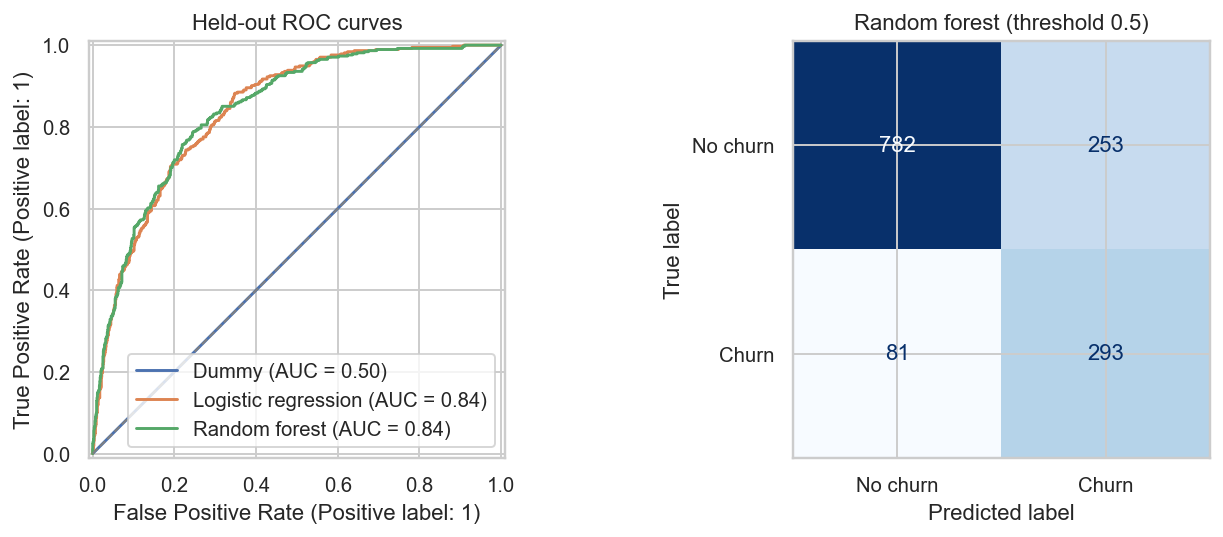

In [10]:
display(Image(filename=str(PROJECT / "figures/07_model_evaluation.png")))

## Descriptive subgroup audit

This post-hoc table is not a fairness certification. It reports group sample sizes, base churn rates, flag rates, recall, false-positive rates and precision for the selected model on the held-out rows.

In [11]:
fairness = ca.fairness_audit(X_test, predictions, OUT)
display(fairness.round(3))

,attribute,group,customers,actual_churners,actual_nonchurners,base_churn_rate,flag_rate,recall,false_positive_rate,precision,tn,fp,fn,tp
0,gender,Female,687,193,494,0.281,0.384,0.756,0.239,0.553,376,118,47,146
1,gender,Male,722,181,541,0.251,0.391,0.812,0.250,0.521,406,135,34,147
2,SeniorCitizen,0,1187,276,911,0.233,0.341,0.746,0.218,0.509,712,199,70,206
3,SeniorCitizen,1,222,98,124,0.441,0.635,0.888,0.435,0.617,70,54,11,87


## Export, reload and demo

The exported pipeline accepts raw predictor columns and performs the same feature engineering and preprocessing. Reloaded probabilities are checked against the fitted model.

In [12]:
demo = ca.export_model(fitted[chosen], X_test, y_test, OUT)
display(demo.round(4))
print("Saved: models/best_model.joblib")
print("Reload probability check: exact equality passed")
print("Final selected model:", chosen)

,customerID,actual_churn,churn_probability,predicted_churn
437,4376-KFVRS,0,0.0383,0
2280,2754-SDJRD,0,0.8588,1
2235,9917-KWRBE,0,0.1660,0


Saved: models/best_model.joblib
Reload probability check: exact equality passed
Final selected model: Random forest


## Interpretation

The model supports prioritising a reviewed retention list. A lower threshold or a fixed contact capacity would change the precision/recall trade-off and must be selected using business costs and validation data. Contract and tenure are associated with churn here, but the sample cannot show that changing them causes customers to stay. The static file also lacks the dated observations needed for a prospective deployment evaluation.